### Discutere la compressione di un’immagine ottenuta approssimandola con diadi calcolate mediante la decomposizione in valori singolari, visualizzando le immagini ottenute al variare del numero p di diadi. Analizzare inoltre i grafici dell’errore relativo e del fattore di compressione cp al variare di p.

In [1]:
import numpy as np
import scipy.linalg
from skimage import data
import matplotlib.pyplot as plt

A = data.horse()

print("\nA.shape", A.shape)


A.shape (328, 400)


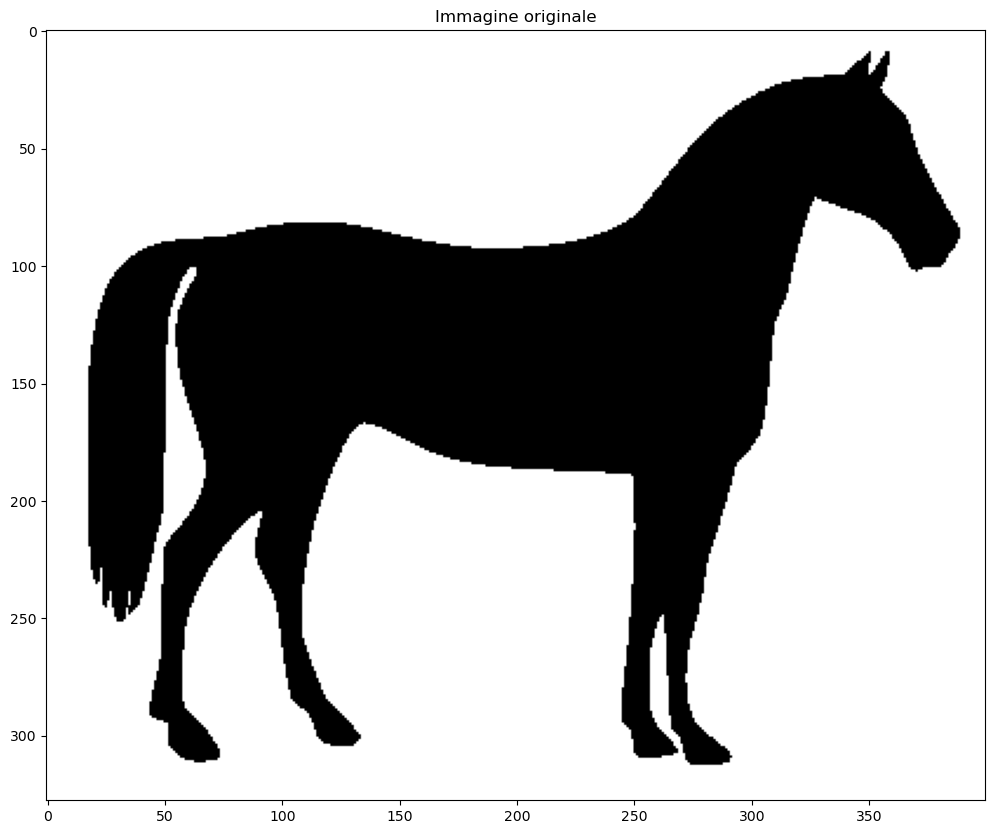

In [2]:
U, s, Vh = scipy.linalg.svd(A)
A_p = np.zeros(A.shape)

plt.figure(figsize=(20, 10)) 
plt.imshow(A, cmap='gray')
plt.title('Immagine originale')
plt.show()

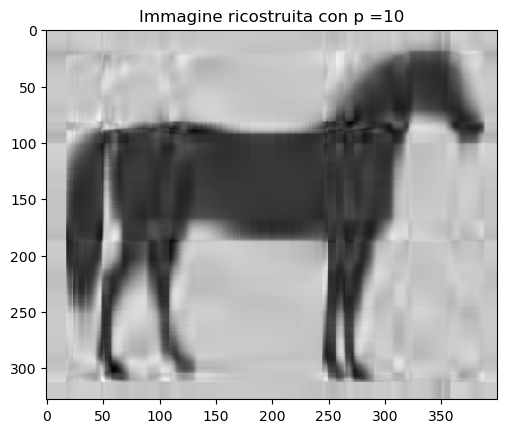

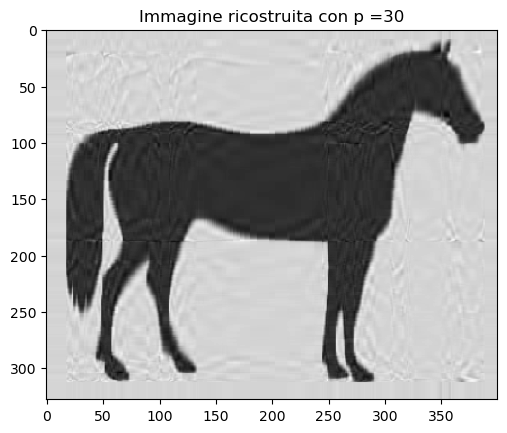

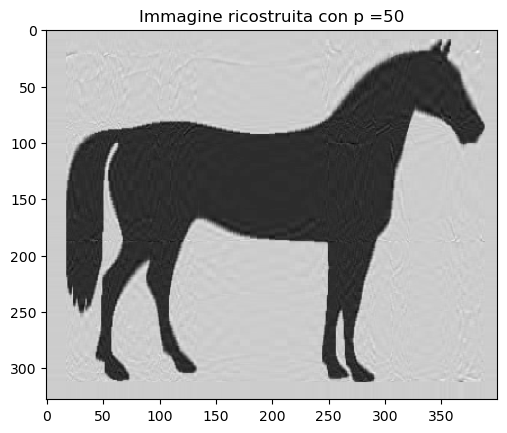

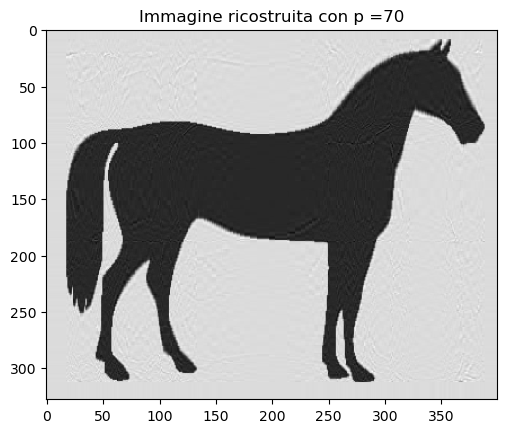

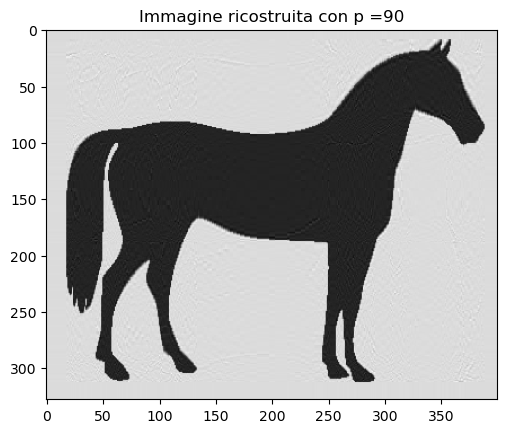

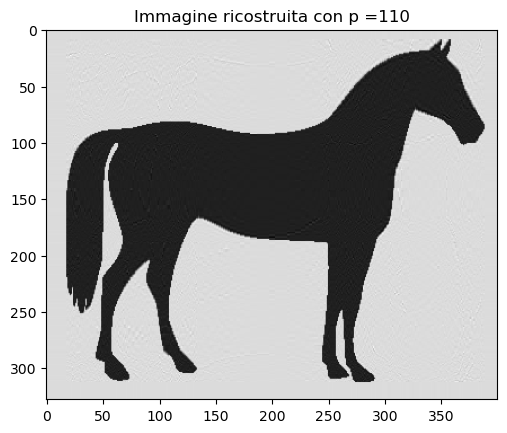

In [3]:
p_max = 100
err_rel = np.zeros((p_max-1)) 
c = np.zeros((p_max-1)) 

for i in range(p_max-1): 
  ui = U[:, i]
  vi = Vh[i, :]

  A_p = A_p + s[i]*np.outer(ui, vi)
  err_rel[i] = np.linalg.norm(A-A_p, "fro")/np.linalg.norm(A, "fro") 
  c[i] = (1/(i+1) * np.min(A.shape))-1 


for i in range(10, 120, 20):  
     A_p = np.matrix(U[:,:i])*np.diag(s[:i])*np.matrix(Vh[:i,:])
     plt.imshow(A_p, cmap='gray')
     plt.title('Immagine ricostruita con p =' + str(i))
     plt.show()

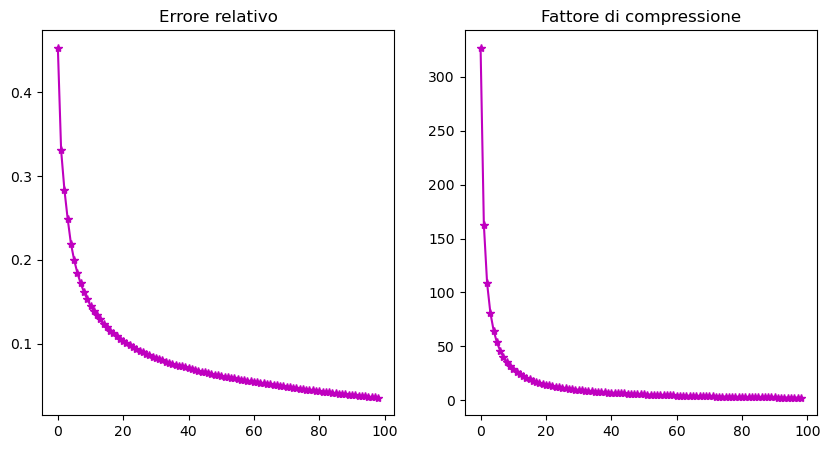

In [4]:
plt.figure(figsize=(10, 5))
fig1 = plt.subplot(1, 2, 1)
fig1.plot(err_rel, 'm-*')
plt.title('Errore relativo') 
fig2 = plt.subplot(1, 2, 2)
fig2.plot(c, 'm-*')
plt.title('Fattore di compressione')  
plt.show()

In [5]:
print('\nL\'errore relativo della ricostruzione di A è =', err_rel[-1])
print('Il fattore di compressione è =', c[-1])


L'errore relativo della ricostruzione di A è = 0.035721503163134175
Il fattore di compressione è = 2.3131313131313136
